In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
model = AutoModelForSequenceClassification.from_pretrained("bucketresearch/politicalBiasBERT")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# 0=left, 1=center, 2=right
label_map = {0: 'left', 1: 'center', 2: 'right'}

def classify_batch(texts, batch_size=32):
    all_labels = []
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        probs = outputs.logits.softmax(dim=-1)
        predicted = probs.argmax(dim=-1).tolist()
        confidence = probs.max(dim=-1).values.tolist()
        all_labels.extend([label_map[p] for p in predicted])
        all_scores.extend(confidence)
    return all_labels, all_scores


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bucketresearch/politicalBiasBERT
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
df = pd.read_pickle('df_with_embeddings.pkl')
texts = df['page_text'].tolist()

labels, scores = classify_batch(texts)
df['predicted_bias'] = labels
df['predicted_bias_score'] = scores

<StringArray>
['left', 'right', 'center']
Length: 3, dtype: str
<StringArray>
['left', 'right', 'center']
Length: 3, dtype: str
              precision    recall  f1-score   support

      center       0.26      0.56      0.35      1478
        left       0.57      0.33      0.42      4881
       right       0.58      0.63      0.61      4473

    accuracy                           0.48     10832
   macro avg       0.47      0.51      0.46     10832
weighted avg       0.53      0.48      0.49     10832



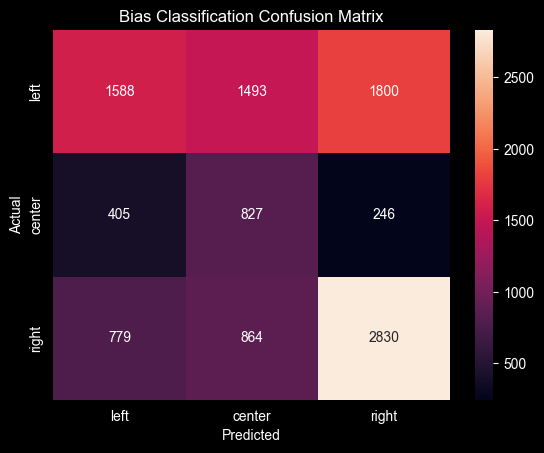

In [4]:
print(df['predicted_bias'].unique())
df['simple_bias'] = 'center'
df.loc[(df['bias'] == 'leaning-left') | (df['bias'] == 'left'), 'simple_bias'] = 'left'
df.loc[(df['bias'] == 'leaning-right') | (df['bias'] == 'right'), 'simple_bias'] = 'right'
print(df['simple_bias'].unique())

print(classification_report(df['simple_bias'], df['predicted_bias']))

# Confusion matrix
cm = confusion_matrix(df['simple_bias'], df['predicted_bias'], labels=['left', 'center', 'right'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['left', 'center', 'right'],
            yticklabels=['left', 'center', 'right'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Bias Classification Confusion Matrix')
plt.show()